# Breast Cancer Classification Problem

In this case, I will deal with the breast cancer dataset.

Here more information about the dataset can be found: https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Diagnostic)

First I will Import the dataset from scikit-learn into a DataFrame called bc. 

In [1]:
from sklearn import datasets
import pandas as pd

breast_cancer = datasets.load_breast_cancer()

print(breast_cancer.keys())

X = breast_cancer.data


bc = pd.DataFrame(X, columns = breast_cancer.feature_names)



dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename'])


Examination of the first 5 rows of the dataset and its shape

In [2]:
bc.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
bc.shape

(569, 30)

Now let's add another column called "diagnosis" and assign it the target variable from the dataset.

In [4]:
bc['diagnosis'] =  breast_cancer.target

In [5]:
bc.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'diagnosis'],
      dtype='object')

In [6]:
bc.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


I will look at how many benign (1) and malign (0) tumor diagnoses are in the dataset?

In [7]:
bc.diagnosis.value_counts()

# 212 malignant and 357 benign tumors

1    357
0    212
Name: diagnosis, dtype: int64

Checking for missing data

In [8]:
bc.isnull().sum()

# no missing data

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
diagnosis                  0
dtype: int64

Outlier detection

<AxesSubplot:>

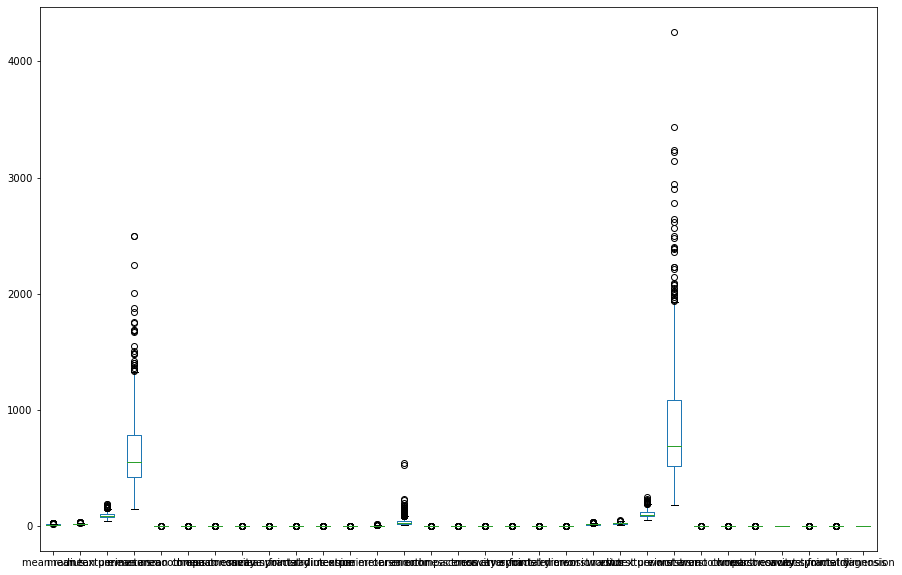

In [9]:
bc.plot.box(figsize=(15,10))

In [10]:
bc.describe()

# the values seem ok. There are some extremes in the worst area column but this could be a really big tumor

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


Plotting histgrams for the different radius parameters for the categories malignant and benign to see which features influence the diagnosis. 

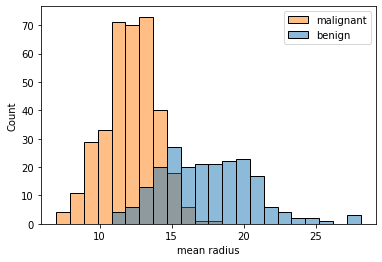

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(x='mean radius',hue='diagnosis',data=bc)
mal = bc[bc["diagnosis"] == 0]
ben = bc[bc["diagnosis"] == 1]
plt.legend(['malignant','benign'])
plt.show()

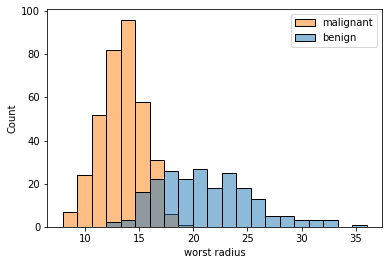

In [12]:
mal = bc[bc["diagnosis"] == 0]
ben = bc[bc["diagnosis"] == 1]
sns.histplot(x='worst radius',hue='diagnosis',data=bc)
plt.legend(['malignant','benign'])
plt.show()

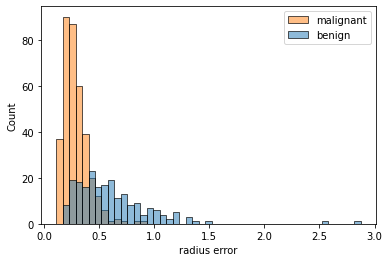

In [13]:
mal = bc[bc["diagnosis"] == 0]
ben = bc[bc["diagnosis"] == 1]
sns.histplot(x='radius error',hue='diagnosis',data=bc)
plt.legend(['malignant','benign'])
plt.show()

In [14]:
# solution: the mean and worst radius have the largest differences in the histograms,
#i.e. belov a value of ~12, almost all tumors are benign, if the values are larger than 
#17 or 20, almost all of them are malign.

Let's try to set up three models using this parameter. Each one should contain one of the all the features containing worst, error and mean in their description. 

In [15]:
bc.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'diagnosis'],
      dtype='object')

In [16]:
mean_cols = ['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension']
error_cols = ['radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error']
worst_cols = ['worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension']

y = bc['diagnosis']

# Logistic Regression

I will choose a logistic regression algorithm for this by dividing dataset into training and testing (80%/20% division). Then I will have a look at the accuracy score for the model's performance.

In [17]:
from sklearn.model_selection import train_test_split
# mean

train_X, test_X, train_y, test_y = train_test_split(
    bc[mean_cols].values, y, test_size=0.2,random_state=0)

In [18]:
train_y.shape

(455,)

In [19]:
from sklearn.linear_model import LogisticRegression
clf_m=LogisticRegression(random_state=0)
clf_m.fit(train_X,train_y)

LogisticRegression(random_state=0)

In [20]:
from sklearn.metrics import accuracy_score
pred_m=clf_m.predict(test_X)
acc_m=accuracy_score(test_y,pred_m)
acc_m

0.9122807017543859

In [21]:
# error

train_X, test_X, train_y, test_y = train_test_split(
    bc[error_cols].values, y, test_size=0.2,random_state=0)

#from sklearn.linear_model import LogisticRegression
clf_e=LogisticRegression(random_state=0)
clf_e.fit(train_X,train_y)
               
#from sklearn.metrics import accuracy_score
pred_e=clf_e.predict(test_X)
acc_e=accuracy_score(test_y,pred_e)
acc_e

0.868421052631579

In [22]:
# worst

train_X, test_X, train_y, test_y = train_test_split(
    bc[error_cols].values, y, test_size=0.2,random_state=0)

#from sklearn.linear_model import LogisticRegression
clf_w=LogisticRegression(random_state=0)
clf_w.fit(train_X,train_y)

#from sklearn.metrics import accuracy_score
pred_w=clf_w.predict(test_X)
acc_w=accuracy_score(test_y,pred_w)
acc_w

0.868421052631579

In [23]:
# solution: The model using the mean columns appears to have the highest accuracy with 91%.

# Performing a randomized search on two decision tree models. 

The parameters max depth, max features, min sample leafs and criterion should be varied.
Perform one search using all features and one search using only the min features.
How much does the accuracy vary between both? Which is the model with the best score?

In [24]:
#import modules
import warnings
from sklearn import model_selection
from sklearn.tree import DecisionTreeClassifier 
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Creating the hyperparameter grid
param_dist = {"max_depth": [3, None],
"max_features": randint(1, 10),
"min_samples_leaf": randint(1, 10),
"criterion": ["gini", "entropy"]}
# Instantiating Decision Tree classifier
tree = DecisionTreeClassifier()
# Instantiating RandomizedSearchCV object
tree_cv = RandomizedSearchCV(tree, param_dist, cv = 5)
tree_cv.fit(bc, y)
# Print the tuned parameters and score
print("Tuned Decision Tree Parameters: {}".format(tree_cv.best_params_))
print("Best score is {}".format(tree_cv.best_score_))

Tuned Decision Tree Parameters: {'criterion': 'gini', 'max_depth': 3, 'max_features': 8, 'min_samples_leaf': 3}
Best score is 0.9929824561403509


In [25]:
# Creating the hyperparameter grid
param_dist = {"max_depth": [3, None],
"max_features": randint(1, 10),
"min_samples_leaf": randint(1, 10),
"criterion": ["gini", "entropy"]}
# Instantiating Decision Tree classifier
tree = DecisionTreeClassifier()
# Instantiating RandomizedSearchCV object
tree_cv = RandomizedSearchCV(tree, param_dist, cv = 5)
tree_cv.fit(bc[mean_cols], y)
# Print the tuned parameters and score
print("Tuned Decision Tree Parameters: {}".format(tree_cv.best_params_))
print("Best score is {}".format(tree_cv.best_score_))

Tuned Decision Tree Parameters: {'criterion': 'gini', 'max_depth': None, 'max_features': 9, 'min_samples_leaf': 7}
Best score is 0.9279770222015215


[[47  0]
 [ 0 67]]


Text(33.0, 0.5, 'True')

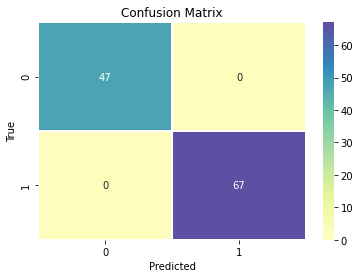

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

train_X, test_X, train_y, test_y = train_test_split(
    bc, y, test_size=0.2,random_state=0)

best_tree = DecisionTreeClassifier(criterion= 'gini', max_depth= None, max_features= 6, min_samples_leaf= 4)
best_tree.fit(train_X, train_y)


best_tree_pred = best_tree.predict(test_X)

cm = confusion_matrix(test_y, best_tree_pred)
print(cm)


import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(cm,vmin=None,
    vmax=None,
    cmap='Spectral',
    center=True,
    linewidths=1,annot=True
)
#annot=True kismini unutma
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')